In [1]:
from pystac_client import Client
import lazycogs
import stac_geoparquet
from pyproj import Transformer
import json
import logging
import configparser
import obstore
import numpy as np
import os
import geopandas as gpd

lazycogs_logger = logging.getLogger("lazycogs")
lazycogs_logger.setLevel(logging.DEBUG)

In [2]:
cdse_stac = Client.open("https://stac.dataspace.copernicus.eu/v1/")

In [3]:
# Near Flathead Lake in Idaho. This area is chosen
# because it spans 9 MGRS tiles and creates enough
# requests to hit the rate limit
search_bbox=[-117.235107, 45.897655, -114.082031,47.978891]

if not os.path.isfile("s1.parquet"):
    s1_item = cdse_stac.search(
        collections="sentinel-1-global-mosaics",
        bbox=search_bbox,
        datetime=None, # get everything
        query={
            "sar:instrument_mode": {"eq": "IW"},
            "sar:polarizations": {"eq": ["VH", "VV"]}
        }
    ).item_collection().to_dict()
    
    stac_geoparquet.to_geodataframe(s1_item["features"], dtype_backend="pyarrow").to_parquet("s1.parquet")

Set up access over S3 to the CDSE bucket. This is a provider-pays bucket, but you have to get your own credentials and quotas apply. See [this link](https://documentation.dataspace.copernicus.eu/APIs/S3.html) for more information.

In [4]:
config = configparser.ConfigParser()
config.read("/home/jovyan/.s3cfg")

access_key = config.get("cdse", "access_key")
secret_key = config.get("cdse", "secret_key")

store = obstore.store.S3Store(
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    bucket="eodata",
    endpoint="https://eodata.dataspace.copernicus.eu"
)

Define output grid

In [5]:
dst_crs = "epsg:32611"
dst_affine = [20.0, 0.0, 699960.0, 0.0, -20.0, 5400000.0]

transformer = Transformer.from_crs("epsg:4326", dst_crs, always_xy=True)
dst_bbox = lazycogs.align_bbox(
    affine=dst_affine,
    bbox=transformer.transform_bounds(*search_bbox),
)
print(dst_bbox)

(481760.0, 5082660.0, 726360.0, 5318080.0)


In [6]:
da = lazycogs.open(
    "s1.parquet",
    store=store,
    bbox=dst_bbox,
    crs=dst_crs,
    resolution=160, # highest overview level to keep memory usage down
    bands=["VV", "VH"],
    nodata=np.nan
)

DEBUG:lazycogs._core:_inspect_first_item took 1.846s, found 2 bands
DEBUG:lazycogs._core:_build_time_steps: Arrow table has 1887 rows
DEBUG:lazycogs._core:_build_time_steps took 0.055s, found 120 time steps
INFO:lazycogs._core:Discovered 2 bands and 120 time steps.
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2015-03-01 returned 16 items in 0.021s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2015-04-01 returned 8 items in 0.021s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2016-03-01 returned 13 items in 0.020s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2016-05-01 returned 16 items in 0.025s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2016-07-01 returned 11 items in 0.023s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2016-08-01 returned 16 items in 0.100s
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH']

In [7]:
da # mem usage peaks at ~9 GB during loading

<xarray.DataArray (band: 2, time: 120, y: 1471, x: 1529)> Size: 2GB
[539798160 values with dtype=float32]
Coordinates:
  * band         (band) <U2 16B 'VV' 'VH'
  * time         (time) datetime64[s] 960B 2015-03-01 2015-04-01 ... 2026-05-01
  * y            (y) float64 12kB 5.318e+06 5.318e+06 ... 5.083e+06 5.083e+06
  * x            (x) float64 12kB 4.818e+05 4.82e+05 ... 7.262e+05 7.263e+05
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:32611)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'schema_url': 'https://raw.githubusercontent.c...
    spatial:dimensions:      ['y', 'x']
    spatial:bbox:            (481760.0, 5082660.0, 726360.0, 5318080.0)
    spatial:transform_type:  affine
    spatial:transform:       [160.0, 0.0, 481760.0, 0.0, -160.0, 5318080.0]
    spatial:shape:           [1471, 1529]
    spatial:registration:    pixel
    proj:code:               EPSG:32611
    _FillValue:              nan

Verify that loading this array will use over 2k requests and will therefore hit the CDSE rate limit.

In [8]:
lazycogs_logger.setLevel(logging.INFO)
da.lazycogs.explain()

ExplainPlan: 2 band(s) x 120 time step(s) x 1 spatial chunk(s) = 240 chunk read(s)
  Grid: 1529x1471 px | COG reads: 3774 (fetch_headers=False)

This will raise warnings in the terminal, but loading will continue regardless. Trying to capture these warnings and immediately raise an exception does not work.

In [9]:
lazycogs_logger.setLevel(logging.DEBUG)

In [10]:
def too_many_requests_filter(record):
    if "Failed to read bands" in record.msg:
        raise RuntimeError("Hit CDSE request limit")
    return True  # Pass through

lazycogs_logger.addFilter(too_many_requests_filter)

The below cell generates lots of output.

In [ ]:
da = da.load()

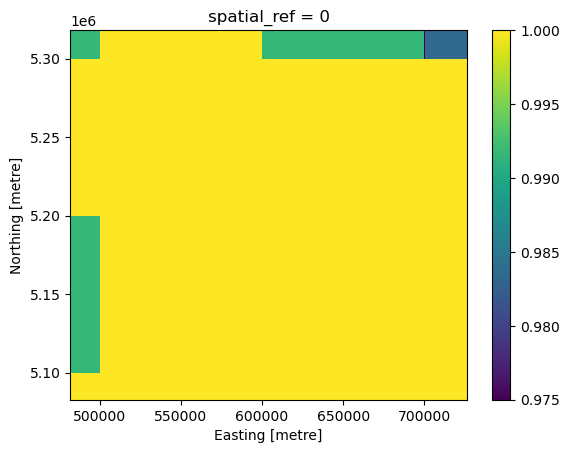

In [12]:
da.isnull().mean(dim=["time", "band"]).plot()